In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from dotenv import find_dotenv, load_dotenv
from langchain_openai import ChatOpenAI

_ = load_dotenv(find_dotenv())
llm = ChatOpenAI(model="gpt-5-nano", temperature=0)

In [3]:
import sys

sys.path.append("../tools")

from fundamental_analysis_tools import evaluate_fundamentals
from IPython.display import Image, display
from langchain.agents import create_agent
from technical_analysis_tools import technical_analysis


# 1. The canonical approach
Single agent with multiple tools. 

> The disadvantage of this approach is tool calling accuracy starts to dip massively once the number of tools increase ([article](https://achan2013.medium.com/how-many-tools-functions-can-an-ai-agent-has-21e0a82b7847))

In [4]:
agent = create_agent(
    model=llm,
    tools=[technical_analysis, evaluate_fundamentals]
)

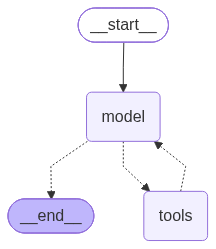

In [5]:
display(Image(
    agent.get_graph(xray=True).draw_mermaid_png()
))

# 2. The Hierarchical Multi-Agent System
Essentially an extension of the canonical approach.

Simply create agents that wrap themselves as a tool for another agent, and have this agent become a tool for the next layer above it.

This setup is known as the **hierarchical** multi-agent system setup, where a supervisor agent has multiple subordinates, who may themselves be a supervisor to another subordinate.

Here's an example:

In [6]:
from langchain.tools import tool
from langgraph_supervisor import create_supervisor

@tool
def get_weather(city: str) -> str:
    """Use this tool to get the weather of a city or location"""
    return f"The weather is sunny in {city}"

weather_expert = create_agent(
    model=llm,
    tools=[get_weather],
    name="weather_expert"
)
technical_analyst_agent = create_agent(
    model=llm,
    tools=[technical_analysis],
    name="technical_analyst"
)
fundamental_analyst_agent = create_agent(
    model=llm,
    tools=[evaluate_fundamentals],
    name="fundamental_analyst"
)

## Creating a supervisor of an analysis team
analysis_squad = create_supervisor(
    [technical_analyst_agent, fundamental_analyst_agent],
    model=llm,
    supervisor_name="analysis_supervisor", #this is important. the supervisor node always takes the name "supervisor so if nesting supervisors, give this a different name to avoid name clashes"
    prompt = (
        "You are a team supervisor managing a fundamental analyst and a "
        "technical analyst. Route technical analysis queries to the "
        "technical analyst and fundamental analysis queries to the "
        "fundamental analyst."
    )
)

analysis_app = analysis_squad.compile(name="fundamental_and_technical_analyst")

## Creating a supervisor of both teams
supervisor_graph = create_supervisor(
    [analysis_app, weather_expert],
    model=llm,
    prompt = (
        "You are a team supervisor managing a fundamental analyst, a "
        "technical analyst and a weather expert. Route technical or "
        "fundamental analysis queries to the fundamental_and_technical_analyst, "
        "and weather queries to the weather_expert"
    )
)

supervisor = supervisor_graph.compile()

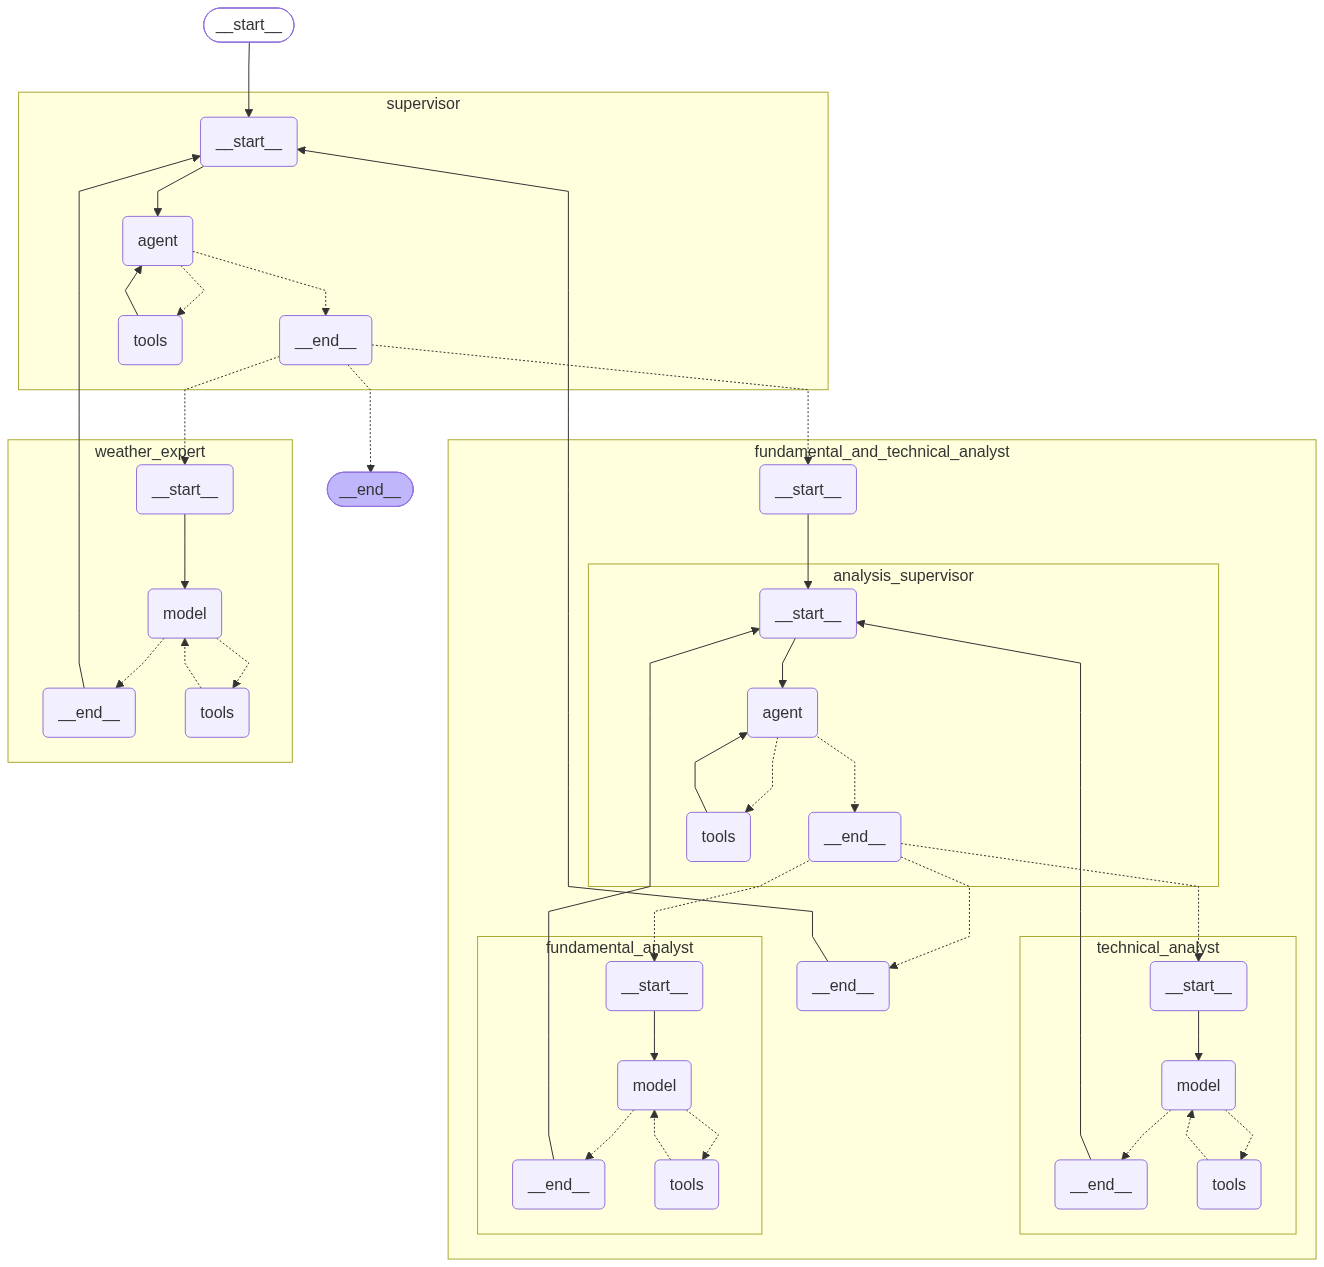

In [7]:
display(Image(
    supervisor.get_graph(xray=True).draw_mermaid_png()
))

But LangChain has explicitly stated that this is not the preferred way. In fact LangGraph Supervisor is kept on live support only for compatibility ([Docs](https://reference.langchain.com/python/langgraph-supervisor)).

LangChain has explicitly stated in its docs that the preferred method is nesting inside tools so that it is easier to orchestrate using `AgentMiddleware`. Which means:

In [8]:
from langchain_core.messages import HumanMessage

@tool
def ask_weather_expert(question: str) -> str:
    """Asks the weather expert a question"""
    response = weather_expert.invoke({
        "messages": [HumanMessage(content=question)]
    })
    return response['messages'][-1].content

@tool
def ask_technical_analyst(question: str) -> str:
    """Asks the technical analyst agent a question."""
    response = technical_analyst_agent.invoke({
        "messages": [HumanMessage(content=question)]
    })
    return response['messages'][-1].content

@tool
def ask_fundamental_analyst(question: str) -> str:
    """Asks the fundamental analyst agent a question."""
    response = fundamental_analyst_agent.invoke({
        "messages": [HumanMessage(content=question)]
    })
    return response['messages'][-1].content

supervisor_agent = create_agent(
    model = llm,
    name = "fundamental_and_technical_analyst",
    tools = [ask_technical_analyst, ask_fundamental_analyst],
    system_prompt="You are a helpful assistant. You have access to two tools: a technical analysis tool and a fundamental analysis. Always use them to answer user queries about stock analysis."
)

@tool
def invoke_analysis_team(question: str) -> str:
    """Invokes the technical and fundamental analysis agents with a question.
    Use for analysis queries relating to technical or fundamental analysis"""
    response = supervisor_agent.invoke({
        "messages": [HumanMessage(content=question)]
    })
    return response['messages'][-1].content

final_agent = create_agent(
    model=llm,
    tools=[invoke_analysis_team, ask_weather_expert]
)

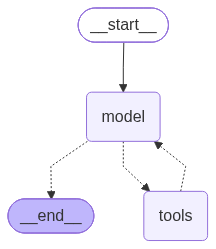

In [9]:
display(Image(
    final_agent.get_graph(xray=True).draw_mermaid_png()
))

The disadvantage is that **everything** is now masked under `tools`. 

# 3. The Custom Pipeline
This approach is a superset of every approach - you essentially construct the entire workflow node by node and edge by edge.

You typically use this if you need to craft a bespoke multi-agent system or want to force control - because in the previous system, the supervisor agent has full control.

Let's say we want to plan the approach out first then seek feedback before executing:

In [10]:
import operator
from typing import Annotated, Literal, TypedDict

from langchain_core.messages import AIMessage
from langchain_core.prompts import (
    ChatPromptTemplate,
)
from langgraph.graph import (
    END,
    START,
    MessagesState,
    StateGraph,
)
from langgraph.types import Command, Send
from pydantic import BaseModel, Field


class UseAgent(BaseModel):
    agent_to_use: Literal[ "technical_analysis_agent", "fundamental_analysis_agent"] = Field(..., description="Agent to use")
    query_to_send: str = Field(..., description="The query to ask this agent")

class Step(BaseModel):
    step_number: int = Field(..., description="The step number in the plan")
    action: UseAgent = Field(
        ..., 
        description= (
            "Action to perform. Use `Respond` if you want to respond to the user "
            "without using a tool. If you need tools, use `UseAgent`. "
        )
    )
    
class Plan(BaseModel):
    steps: list[Step] = Field(..., description="The list of steps in the plan")

## 1. Plan
planner_prompt = ChatPromptTemplate.from_template(
    """For a given objective, come up with a simple step by step plan to
    acquire the information required to achieve the objective.
    
    The plan should involve individual tasks only.
    
    <important>
        Invoke the fundamental_analysis_agent and technical_analysis_agent only once per company of interest.
        If there are two companies of interest, invoke the respective agent/s twice.
        Always use both agents to analyze stock market data when evaluating investments.
    </important>
    
    The user's question is: {objective}
    """
)

llm_planner = planner_prompt | llm.with_structured_output(Plan)

Step 2 routes the individual elements of the plan to the sub agents

In [11]:
class ToolCall(TypedDict):
    tool_name: str
    time_start: str
    time_end: str
    tool_result: str

class State(MessagesState):
    tool_calls: Annotated[list[ToolCall], operator.add]

## We'll use LangGraph's `Command` and `Send` to route to sub agents
def execute_plan(
    plan: Plan, state: State
) -> Command[Literal["fundamental_analysis_agent", "technical_analysis_agent", "respond"]]:    
    """This function routes plan steps to the respective nodes"""
    
    gotos = []
    if len(plan.steps) > 1:        
        for step in plan.steps:
            if isinstance(step.action, UseAgent):
                gotos.append(
                    Send(
                        step.action.agent_to_use,
                        {'query': step.action.query_to_send}
                    )
                )
    else:
        gotos.append(Send("respond", {"messages": state['messages']}))
    
    return Command(goto=gotos)

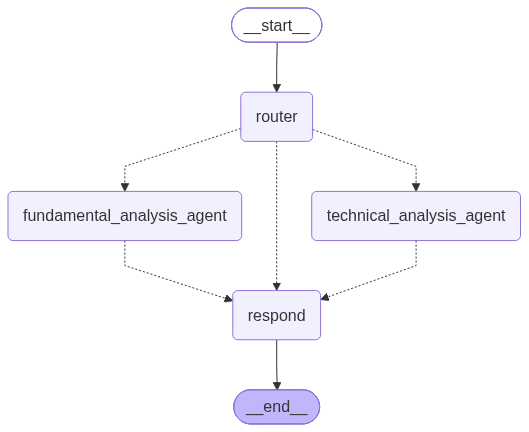

In [12]:
import time
from datetime import datetime
from uuid import uuid4


def get_datetime() -> str:    
    return datetime.fromtimestamp(time.time()).strftime("%Y-%m-%d %H:%M:%S")  # noqa: DTZ006

## 2. Route to sub agents after plan
def router(state: State) -> Command[
    Literal["fundamental_analysis_agent", "technical_analysis_agent", "respond"]
]:
    # Get plan
    query = state['messages'][-1].content
    response = llm_planner.invoke(query) #invoke planner
    return execute_plan(response, state)

## 3. Sub agent nodes
def technical_analysis_agent(state: State) -> Command[Literal["respond"]]:    
    start_time = get_datetime()
    ta_agent = create_agent(model=llm, tools=[technical_analysis])
    response = ta_agent.invoke({'messages': [HumanMessage(content=state['query'])]})    
    end_time = get_datetime()
    return Command(
        goto = "respond",
        update = {
            "messages": [AIMessage(content=response['messages'][-1].content, tool_call_id=uuid4().hex)],
            "tool_calls": [
                ToolCall(
                    time_start = start_time,
                    time_end = end_time,
                    tool_result = response,
                    tool_name = "technical_analysis"
                )
            ]
        }        
    )

def fundamental_analysis_agent(state: State) -> Command[Literal["respond"]]:
    start_time = get_datetime()
    fa_agent = create_agent(model=llm, tools=[evaluate_fundamentals])
    response = fa_agent.invoke({'messages': [HumanMessage(content=state['query'])]})
    end_time = get_datetime()
    return Command(
        goto = "respond",
        update = {
            "messages": [AIMessage(content=response['messages'][-1].content, tool_call_id=uuid4().hex)],
            "tool_calls": [
                ToolCall(
                    time_start = start_time,
                    time_end = end_time,
                    tool_result = response,
                    tool_name = "fundamental_analysis"
                )
            ]
        } 
    )


## 4. A node to consolidate responses from subagents
def respond(state: State):
    return {'messages': [llm.invoke(state['messages'])]}

graph = StateGraph(State)

graph.add_node("router", router)
graph.add_node("technical_analysis_agent", technical_analysis_agent)
graph.add_node("fundamental_analysis_agent", fundamental_analysis_agent)
graph.add_node("respond", respond)

graph.add_edge(START, "router")
graph.add_edge("respond", END)

agent = graph.compile()

display(Image(agent.get_graph().draw_mermaid_png()))

In this case the workflow is flexible enough to hit either or both of these nodes **at the same time**. 

If you ask two fundamental analysis related questions, the workflow is even flexible enough to invoke the `fundamental_analysis_agent` twice, concurrently.

> Do bear in mind that now both agents **will always** route their responses to the `respond` node. This workflow is **acyclic**. There is no replanning or refinement of plan. The solution to this is of course more nodes and edges

# 4. Agent Swarm
This multi-agent system is special - every agent talks to every other agent. Which means that every agent is a tool to every agent.

The thinking is to use an "Agent Society" where agents collaborate together to finally determine the answer.

In [13]:
from langgraph_swarm import (  # pyright: ignore[reportMissingImports]
    create_handoff_tool,
    create_swarm,
)

## We'll have to redefine our 3 agents to include the handoff tool
weather_expert = create_agent(
    model=llm,
    tools=[
        get_weather,
        create_handoff_tool(
            agent_name="technical_analyst",
            description="Transfer for technical analysis related questions"
        ),
        create_handoff_tool(
            agent_name="fundamental_analyst",
            description="Transfer for fundamental analysis related questions"
        ),
    ],
    name="weather_expert"
)
technical_analyst_agent = create_agent(
    model=llm,
    tools=[
        technical_analysis,
        create_handoff_tool(
            agent_name="fundamental_analyst",
            description="Transfer for fundamental analysis related questions"
        ),
        create_handoff_tool(
            agent_name="weather_expert",
            description="Transfer for weather related questions"
        ),
    ],
    name="technical_analyst"
)
fundamental_analyst_agent = create_agent(
    model=llm,
    tools=[
        evaluate_fundamentals,
        create_handoff_tool(
            agent_name="weather_expert",
            description="Transfer for weather related questions"
        ),
        create_handoff_tool(
            agent_name="technical_analyst",
            description="Transfer for technical analysis related questions"
        ),
    ],
    name="fundamental_analyst"
)

swarm_workflow = create_swarm(
    [fundamental_analyst_agent, technical_analyst_agent, weather_expert],
    default_active_agent="weather_expert" #a default agent must be specified.
)

swarm = swarm_workflow.compile()

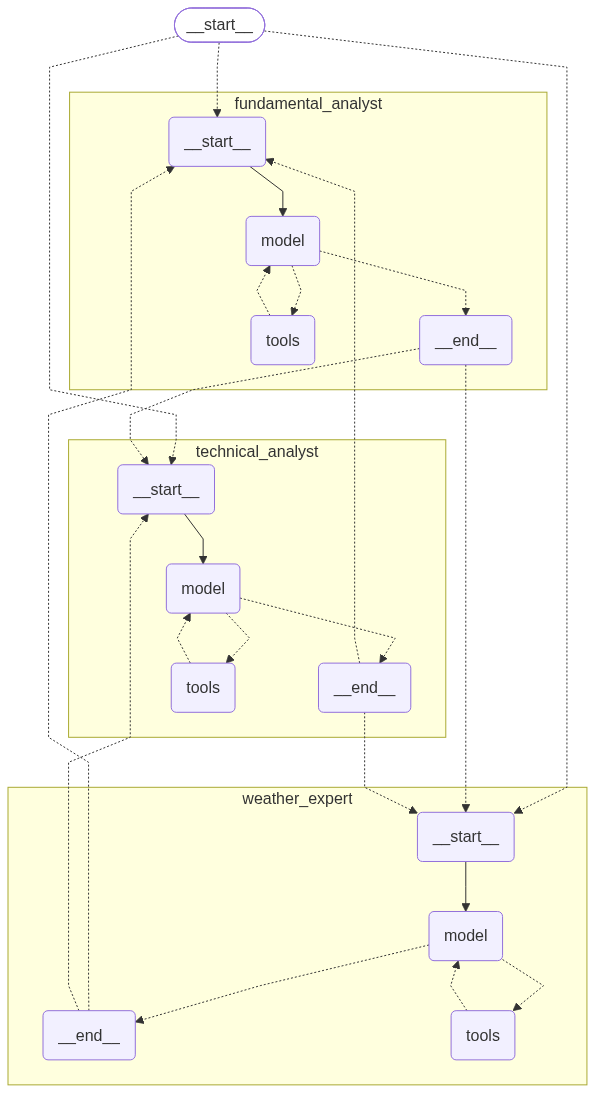

In [14]:
display(Image(
    swarm.get_graph(xray=True).draw_mermaid_png()
))

# 5. Blackboard Multi-Agent System
Agents do not talk to each other directly.

Instead they work around a shared, central data repository called a "blackboard". When one agent writes a partial solution or data to the blackboard, the specialists read it, evaluate if they can improve or expand upon it and write their updates back.

---
  1. THE BLACKBOARD    - a structured, shared solution space, partitioned into
                         "levels" or "panels". NOT a chat log. This is the single
                         most important difference from every other pattern.
 
  2. KNOWLEDGE SOURCES - independent specialists. Each declares a PRECONDITION
                         ("I can contribute when the board looks like X") and an
                         ACTION ("...and here's what I'll write"). Knowledge
                         sources NEVER communicate with each other. They don't
                         even know each other exists. All coordination is
                         mediated by the board.
 
  3. CONTROL COMPONENT - inspects the board each cycle, works out which
                         knowledge sources are ELIGIBLE, and activates one.
                         This is "opportunistic control": the next move is a
                         function of the current partial solution, not of the
                         original query.
 
The control loop is: inspect -> activate -> contribute -> inspect -> ...
until no knowledge source is eligible. Termination is a property of the BOARD,
not a decision any agent makes.
 
Deliberately sequential: only one knowledge source fires per cycle, because each
contribution changes what is opportunistically relevant next. Parallel fan-out
would destroy exactly the property that makes this a blackboard.

> Reference: [Blackboard Architectures, Stanford University](https://stacks.stanford.edu/file/druid:nh044zx3884/nh044zx3884.pdf)

In [ ]:
import operator
from collections.abc import Callable
from dataclasses import dataclass
from typing import Any

from langchain_core.tools import BaseTool

# Safety valve so a misbehaving trigger can't spin forever.
MAX_CYCLES = 12

class Contribution(TypedDict):
    """One knowledge source's write to the board. The audit trail."""
 
    cycle: int
    source: str
    panel: str
    summary: str
 
 
class Blackboard(TypedDict, total=False):
    # ---- Level 0: the problem statement (written once, at the start) --------
    query: str
 
    # ---- Level 1: the problem frame (extracted entities) -------------------
    problem_framed: bool
    ticker: str | None
    location: str | None
    wants_technical: bool
    wants_fundamental: bool
 
    # ---- Level 2: specialist findings, one panel per knowledge source -------
    technical: dict[str, Any] | None
    fundamental: dict[str, Any] | None
    environmental: dict[str, Any] | None
 
    # ---- Level 3: the integrated hypothesis --------------------------------
    synthesis: str | None
 
    # ---- Control plane -----------------------------------------------------
    contributions: Annotated[list[Contribution], operator.add]
    trace: Annotated[list[str], operator.add]
    next_ks: str | None
    cycles: int
 

In [27]:

# =============================================================================
# 2. KNOWLEDGE SOURCE PRECONDITIONS
# =============================================================================
# Pure predicates over the board. No LLM, no side effects, no knowledge of any
# other knowledge source. Each one answers a single question: "given what is
# currently written on the board, do I have anything to add?"
#
# Read these top to bottom and you can see the whole control logic of the system
# without reading a single agent implementation. That's the payoff of the
# pattern.
 
 
def can_frame_problem(bb: Blackboard) -> bool:
    """Nothing can happen until we know what we're actually looking at."""
    return not bb.get("problem_framed", False)
 
 
def can_analyse_technicals(bb: Blackboard) -> bool:
    """Needs a ticker AND the user actually asked for technicals.
 
    Gating on intent is what lets the board stay minimal -- only 
    the panels that are actually relevant ever fill in.
    """
    return (
        bb.get("ticker") is not None
        and bb.get("wants_technical", False)
        and bb.get("technical") is None
    )
 
 
def can_analyse_fundamentals(bb: Blackboard) -> bool:
    """Same shape, different panel. These two remain peers, not a sequence."""
    return (
        bb.get("ticker") is not None
        and bb.get("wants_fundamental", False)
        and bb.get("fundamental") is None
    )
 
 
def can_check_weather(bb: Blackboard) -> bool:
    """Only fires if the frame actually surfaced a location. Opportunistic:
    on a pure stock query this knowledge source simply never activates, and
    nobody had to write a rule saying so."""
    return bb.get("location") is not None and bb.get("environmental") is None
 
 
def can_synthesise(bb: Blackboard) -> bool:
    """Needs at least one finding to integrate, and no synthesis yet.
 
    Note there is no 'wait until everyone is done' condition here. It doesn't
    need one: the priority ordering below means the synthesiser is simply the
    lowest-priority eligible source, so it wins only once the specialists have
    exhausted themselves. Sequencing emerges from the control policy rather
    than being hardcoded into the trigger.
    """
    has_findings = any(
        bb.get(panel) is not None
        for panel in ("technical", "fundamental", "environmental")
    )
    return has_findings and bb.get("synthesis") is None
 
 
@dataclass(frozen=True)
class KnowledgeSource:
    """A knowledge source is a trigger + a node + a priority. That's it."""
 
    name: str
    trigger: Callable[[Blackboard], bool]
    priority: int  # higher wins when several are eligible
 
 
KNOWLEDGE_SOURCES: list[KnowledgeSource] = [
    KnowledgeSource("frame_problem", can_frame_problem, priority=100),
    KnowledgeSource("technical_analyst", can_analyse_technicals, priority=50),
    KnowledgeSource("fundamental_analyst", can_analyse_fundamentals, priority=50),
    KnowledgeSource("weather_expert", can_check_weather, priority=40),
    KnowledgeSource("synthesiser", can_synthesise, priority=10),
]

In [28]:
# =============================================================================
# 3. THE CONTROL COMPONENT
# =============================================================================
 
 
def control_component(bb: Blackboard) -> dict:
    """Inspect the board, pick the next knowledge source to activate.
 
    This is a real node rather than a bare conditional edge, on purpose: in a
    blackboard system the controller is a first-class component, and making it
    a node means every control decision shows up in the graph and the trace.
    """
    cycle = bb.get("cycles", 0) + 1
 
    if cycle > MAX_CYCLES:
        return {
            "cycles": cycle,
            "next_ks": None,
            "trace": [f"[cycle {cycle}] control: MAX_CYCLES hit, halting"],
        }
 
    eligible = [ks for ks in KNOWLEDGE_SOURCES if ks.trigger(bb)]
 
    if not eligible:
        return {
            "cycles": cycle,
            "next_ks": None,
            "trace": [f"[cycle {cycle}] control: no eligible sources, solution quiescent"],
        }
 
    # Opportunistic activation: highest priority among those whose preconditions
    # the current board state satisfies. Swap this for an LLM call and you have
    # a learned control policy without touching anything else in the system.
    chosen = max(eligible, key=lambda ks: ks.priority)
    names = ", ".join(ks.name for ks in eligible)
 
    return {
        "cycles": cycle,
        "next_ks": chosen.name,
        "trace": [f"[cycle {cycle}] control: eligible=[{names}] -> activating {chosen.name}"],
    }
 
 
def route_from_control(bb: Blackboard) -> str:
    """Conditional edge. Reads the decision the controller already made."""
    return bb.get("next_ks") or END

In [29]:

# =============================================================================
# 4. HELPERS
# =============================================================================
  
class ProblemFrame(BaseModel):
    """Structured read of the user's request."""
 
    ticker: str | None = Field(
        None,
        description="Stock ticker symbol mentioned or implied, uppercase (e.g. AAPL). Null if none.",
    )
    location: str | None = Field(
        None,
        description="City or location, only if the user asks about weather. Null otherwise.",
    )
    wants_technical: bool = Field(
        False,
        description=(
            "True if the user is asking for technical/chart/momentum/price-action "
            "analysis specifically."
        ),
    )
    wants_fundamental: bool = Field(
        False,
        description=(
            "True if the user is asking for fundamental/valuation/financial-health "
            "analysis specifically. If the user just says 'analyse this stock' with "
            "no qualifier, treat that as wanting BOTH."
        ),
    )
 
 
def render_board(bb: Blackboard) -> str:
    """Render the board as text for a knowledge source to read.
 
    This is the crux of the pattern. A knowledge source is handed a VIEW OF THE
    BOARD, not a conversation history. It answers "what can I add to this?"
    rather than "what should I say next?".
    """
    lines = [f"PROBLEM: {bb.get('query', '(none)')}"]
 
    if bb.get("ticker"):
        lines.append(f"TICKER: {bb['ticker']}")
    if bb.get("location"):
        lines.append(f"LOCATION: {bb['location']}")
 
    for panel in ("technical", "fundamental", "environmental"):
        value = bb.get(panel)
        lines.append(
            f"\n[{panel.upper()} PANEL]\n{value['finding'] if value else '(empty)'}"
        )
 
    return "\n".join(lines)
 
 
def _last_text(result: dict) -> str:
    """Pull the final assistant message out of a create_agent invocation."""
    return result["messages"][-1].content

In [30]:
# =============================================================================
# 5. BUILD THE SYSTEM
# =============================================================================
 
 
def build_blackboard_system(
    llm: ChatOpenAI,
    technical_analysis: BaseTool,
    fundamental_analysis: BaseTool,
    get_weather: BaseTool,
):
    """Wire up the blackboard, the knowledge sources, and the control loop.
 
    Args:
        llm: any LangChain chat model.
        technical_analysis / fundamental_analysis / get_weather: your @tool functions.
 
    Returns:
        A compiled LangGraph app. Invoke with {"query": "..."}.
    """
 
    # -- Knowledge source agents ------------------------------------------
    # Each gets exactly one tool and knows nothing about its peers. No handoff
    # tools anywhere in this file -- that's the swarm pattern, and its presence
    # would be the tell that this isn't really a blackboard.
 
    technical_agent = create_agent(
        model=llm,
        tools=[technical_analysis],
        system_prompt=(
            "You are a technical analysis specialist contributing to a shared "
            "analysis board. Use your tool on the ticker given. Report only what "
            "technical analysis supports: trend, momentum, key levels, signal. "
            "Do not speculate about fundamentals or anything outside your remit. "
            "Be concise and concrete."
        ),
        name="technical_analyst",
    )
 
    fundamental_agent = create_agent(
        model=llm,
        tools=[fundamental_analysis],
        system_prompt=(
            "You are a fundamental analysis specialist contributing to a shared "
            "analysis board. Use your tool on the ticker given. Report only what "
            "the fundamentals support: valuation, financial health, growth, "
            "quality. Do not comment on price action or chart signals. "
            "Be concise and concrete."
        ),
        name="fundamental_analyst",
    )
 
    weather_agent = create_agent(
        model=llm,
        tools=[get_weather],
        system_prompt=(
            "You are a weather specialist contributing to a shared analysis "
            "board. Use your tool on the location given and report the "
            "conditions plainly. Nothing else."
        ),
        name="weather_expert",
    )
 
    # -- Knowledge source nodes -------------------------------------------
    # Each node: read the board -> do your one job -> write your own panel.
    # Note that none of them touch a panel other than their own. 
 
    def frame_problem(bb: Blackboard) -> dict:
        """Distills the problem into components"""
        framer = llm.with_structured_output(ProblemFrame)
        frame = framer.invoke(
            [
                HumanMessage(
                    content=(
                        "Extract the ticker and/or location from this request. "
                        "Use null for anything not present.\n\n"
                        f"Request: {bb['query']}"
                    )
                )
            ]
        )
        cycle = bb.get("cycles", 0)
        return {
            "problem_framed": True,
            "ticker": frame.ticker,
            "location": frame.location,
            "wants_technical": frame.wants_technical,
            "wants_fundamental": frame.wants_fundamental,
            "contributions": [
                Contribution(
                    cycle=cycle,
                    source="frame_problem",
                    panel="frame",
                    summary=(
                        f"ticker={frame.ticker}, location={frame.location}, "
                        f"wants_technical={frame.wants_technical}, "
                        f"wants_fundamental={frame.wants_fundamental}"
                    ),
                )
            ],
            "trace": [
                f"  frame_problem wrote: ticker={frame.ticker}, location={frame.location}, "  # noqa: ISC004
                f"wants_technical={frame.wants_technical}, wants_fundamental={frame.wants_fundamental}"
            ],
        }
 
    def technical_analyst(bb: Blackboard) -> dict:
        result = technical_agent.invoke(
            {
                "messages": [
                    HumanMessage(
                        content=(
                            "Here is the current state of the analysis board. "
                            "Add your technical assessment.\n\n"
                            f"{render_board(bb)}"
                        )
                    )
                ]
            }
        )
        finding = _last_text(result)
        return {
            "technical": {"finding": finding, "source": "technical_analyst"},
            "contributions": [
                Contribution(
                    cycle=bb.get("cycles", 0),
                    source="technical_analyst",
                    panel="technical",
                    summary=finding[:120],
                )
            ],
            "trace": ["  technical_analyst wrote to [TECHNICAL] panel"],
        }
 
    def fundamental_analyst(bb: Blackboard) -> dict:
        result = fundamental_agent.invoke(
            {
                "messages": [
                    HumanMessage(
                        content=(
                            "Here is the current state of the analysis board. "
                            "Add your fundamental assessment.\n\n"
                            f"{render_board(bb)}"
                        )
                    )
                ]
            }
        )
        finding = _last_text(result)
        return {
            "fundamental": {"finding": finding, "source": "fundamental_analyst"},
            "contributions": [
                Contribution(
                    cycle=bb.get("cycles", 0),
                    source="fundamental_analyst",
                    panel="fundamental",
                    summary=finding[:120],
                )
            ],
            "trace": ["  fundamental_analyst wrote to [FUNDAMENTAL] panel"],
        }
 
    def weather_expert(bb: Blackboard) -> dict:
        result = weather_agent.invoke(
            {
                "messages": [
                    HumanMessage(
                        content=(
                            "Here is the current state of the analysis board. "
                            "Add the weather conditions.\n\n"
                            f"{render_board(bb)}"
                        )
                    )
                ]
            }
        )
        finding = _last_text(result)
        return {
            "environmental": {"finding": finding, "source": "weather_expert"},
            "contributions": [
                Contribution(
                    cycle=bb.get("cycles", 0),
                    source="weather_expert",
                    panel="environmental",
                    summary=finding[:120],
                )
            ],
            "trace": ["  weather_expert wrote to [ENVIRONMENTAL] panel"],
        }
 
    def synthesiser(bb: Blackboard) -> dict:
        """The integrator. Reads every panel, writes the top-level hypothesis.
        """
        response = llm.invoke(
            [
                HumanMessage(
                    content=(
                        "You are the integrator on a shared analysis board. Several "
                        "independent specialists have written their findings below. "
                        "Produce one coherent answer to the original problem.\n\n"
                        "Rules:\n"
                        "- Use only what is on the board. Do not invent findings.\n"
                        "- If panels disagree, say so explicitly rather than "
                        "papering over it.\n"
                        "- Note anything the board does not cover.\n\n"
                        f"{render_board(bb)}"
                    )
                )
            ]
        )
        synthesis = response.content
        return {
            "synthesis": synthesis,
            "contributions": [
                Contribution(
                    cycle=bb.get("cycles", 0),
                    source="synthesiser",
                    panel="synthesis",
                    summary=synthesis[:120],
                )
            ],
            "trace": ["  synthesiser wrote to [SYNTHESIS] panel"],
        }
 
    # -- Wire the control loop --------------------------------------------
    graph = StateGraph(Blackboard)
 
    graph.add_node("control", control_component)
    graph.add_node("frame_problem", frame_problem)
    graph.add_node("technical_analyst", technical_analyst)
    graph.add_node("fundamental_analyst", fundamental_analyst)
    graph.add_node("weather_expert", weather_expert)
    graph.add_node("synthesiser", synthesiser)
 
    graph.add_edge(START, "control")
 
    # The controller fans out to whichever knowledge source it activated.
    graph.add_conditional_edges(
        "control",
        route_from_control,
        {
            "frame_problem": "frame_problem",
            "technical_analyst": "technical_analyst",
            "fundamental_analyst": "fundamental_analyst",
            "weather_expert": "weather_expert",
            "synthesiser": "synthesiser",
            END: END,
        },
    )
 
    # ...and every knowledge source returns control to the board. This is the
    # cycle. No knowledge source ever edges directly to another one -- if you
    # ever find yourself adding such an edge, you've left the pattern.
    for ks in KNOWLEDGE_SOURCES:
        graph.add_edge(ks.name, "control")
 
    return graph.compile(name="blackboard_system")

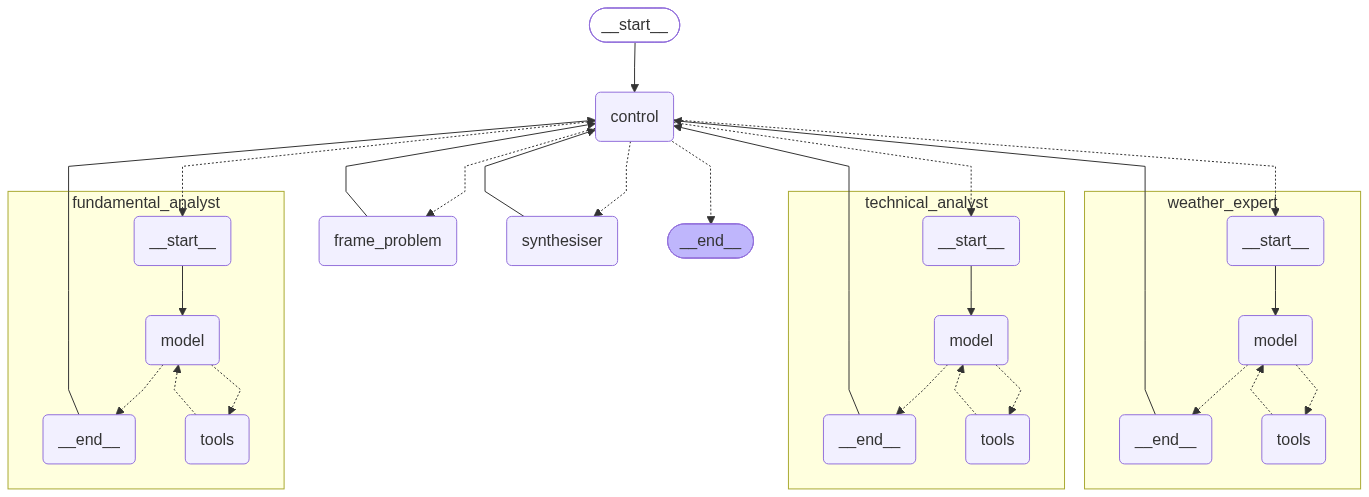

In [31]:
app = build_blackboard_system(
    llm, technical_analysis, evaluate_fundamentals, get_weather
)

display(Image(
    app.get_graph(xray=True).draw_mermaid_png()
))

In [26]:
query = "Undertake a technical analysis of NVIDIA shares? Also what's the weather in Singapore?"

for step in app.stream(
    {"query": query}, stream_mode="updates"
):
    print(step)

{'control': {'cycles': 1, 'next_ks': 'frame_problem', 'trace': ['[cycle 1] control: eligible=[frame_problem] -> activating frame_problem']}}
{'frame_problem': {'problem_framed': True, 'ticker': 'NVDA', 'location': 'Singapore', 'wants_technical': True, 'wants_fundamental': False, 'contributions': [{'cycle': 1, 'source': 'frame_problem', 'panel': 'frame', 'summary': 'ticker=NVDA, location=Singapore, wants_technical=True, wants_fundamental=False'}], 'trace': ['  frame_problem wrote: ticker=NVDA, location=Singapore, wants_technical=True, wants_fundamental=False']}}
{'control': {'cycles': 2, 'next_ks': 'technical_analyst', 'trace': ['[cycle 2] control: eligible=[technical_analyst, weather_expert] -> activating technical_analyst']}}
{'technical_analyst': {'technical': {'finding': ' NVDA — technical assessment (Singapore location)\n\nTrend\n- ADI (Accumulation/Distribution): bullish signal (buy)\n- MACD: bullish signal (price momentum above signal)\n- Aroon: no clear trend change (neutral/wai

# 6. Actor-Critic

The naive version is actor <-> critic, looping until the critic is happy.
That system never terminates reliably, because a critic prompted to "be harsh"
will always find something. Harshness is the point -- but it means the critic
must NOT hold the stop button.
 
So the critic only *reports*. A separate judge decides whether the reported
issues actually warrant another round. Splitting "find problems" from "decide
if problems matter" is the whole trick: it lets you crank critic severity all
the way up without the loop becoming immortal.

> Note: This is NOT a GAN. No gradients, no weight updates, and critically: the actor is NOT trying to
deceive the critic. Both are optimising for the same thing -- a better final
artifact. This is automated hostile code review, not a min-max game.

Important design consideration: How do you handle a stalemate?

In [ ]:
# =============================================================================
# STRUCTURED OUTPUTS
# =============================================================================

HARD_ROUND_CAP = 5
STALEMATE_WINDOW = 3  # rounds of non-improvement before we call it

class Issue(BaseModel):
    severity: Literal["blocking", "major", "minor"] = Field(
        description="blocking = must fix; major = should fix; minor = nitpick"
    )
    description: str = Field(description="Specific, actionable. No vague hand-waving.")
 
 
class Critique(BaseModel):
    issues: list[Issue] = Field(default_factory=list)
    summary: str = Field(description="One line on the draft's overall state.")
 
 
class Verdict(BaseModel):
    decision: Literal["accept", "revise"]
    reasoning: str
    focus: str = Field(
        default="",
        description="If revising: what the actor should prioritise this round.",
    )

In [33]:
# =============================================================================
# STATE
# =============================================================================

class AdversarialState(TypedDict, total=False):
    task: str
    draft: str
 
    latest_critique: dict[str, Any] | None
    latest_verdict: dict[str, Any] | None
 
    # Countable convergence signal. This is what the watchdog reads.
    issue_counts: Annotated[list[int], operator.add]
 
    round: int
    halt_reason: str | None
    trace: Annotated[list[str], operator.add]
 
 
def _weighted_issue_score(issues: list[dict]) -> int:
    """Blocking issues count more than nitpicks.
 
    Using a raw len() would let the loop look 'stuck' when it's actually
    converting blockers into minors -- which is real progress.
    """
    weights = {"blocking": 5, "major": 2, "minor": 1}
    return sum(weights.get(i["severity"], 1) for i in issues)

In [38]:
# =============================================================================
# WATCHDOG -- deterministic, no LLM, no vote
# =============================================================================
 
 
def watchdog(state: AdversarialState) -> dict:
    rnd = state.get("round", 0)
    counts = state.get("issue_counts", [])
 
    if rnd >= HARD_ROUND_CAP:
        return {
            "halt_reason": f"hard round cap ({HARD_ROUND_CAP}) reached",
            "trace": [f"  [watchdog] HALT: round cap {rnd}/{HARD_ROUND_CAP}"],
        }
 
    # Stalemate: over the last STALEMATE_WINDOW scores, no net improvement.
    if len(counts) >= STALEMATE_WINDOW:
        window = counts[-STALEMATE_WINDOW:]
        if window[-1] >= window[0]:
            return {
                "halt_reason": (
                    f"stalemate: issue score {window} showed no improvement "
                    f"over {STALEMATE_WINDOW} rounds"
                ),
                "trace": [f"  [watchdog] HALT: stalemate, scores={window}"],
            }
 
    return {"trace": [f"  [watchdog] ok, scores={counts}"]}
 
 
def route_after_watchdog(state: AdversarialState) -> str:
    return END if state.get("halt_reason") else "judge"
 
 
def route_after_judge(state: AdversarialState) -> str:
    verdict = state.get("latest_verdict") or {}
    return "actor" if verdict.get("decision") == "revise" else END

## This function handles tiebreaks
def finalize(state: AdversarialState) -> dict:
    """The one node every exit path runs through. Decides what actually goes
    back to the caller -- and never lets a stalemate or cap halt look like a
    clean success.
 
    Deterministic on purpose: this node's whole job is accurately reporting
    what the critic already found. Routing that through another LLM call
    would let the summary itself hallucinate -- the one place in this system
    that most needs to not do that.
    """
    halt_reason = state.get("halt_reason")
    verdict = state.get("latest_verdict") or {}
    critique = state.get("latest_critique") or {"issues": []}
    draft = state["draft"]
 
    clean_accept = halt_reason is None and verdict.get("decision") == "accept"
 
    if clean_accept:
        return {
            "final_output": draft,
            "outcome": "accepted",
            "trace": ["  [finalize] outcome=accepted, no caveats"],
        }
 
    outcome = "capped" if halt_reason and "cap" in halt_reason else "stalemate"
    outstanding = [
        i for i in critique["issues"] if i["severity"] in ("blocking", "major")
    ]
 
    if outstanding:
        issue_lines = "\n".join(
            f"- [{i['severity']}] {i['description']}" for i in outstanding
        )
        caveat = (
            f"\n\n---\n**⚠️ This answer did not pass full review "
            f"({halt_reason}).**\n"
            f"Unresolved issues from the last critique round:\n{issue_lines}\n\n"
            f"Treat the above with appropriate skepticism."
        )
    else:
        # Loop was halted (cap/stalemate) but the last critique round happened
        # to come back clean on blocking/major issues -- still worth saying so.
        caveat = (
            f"\n\n---\n_Review loop ended early ({halt_reason}), but no "
            f"blocking or major issues were outstanding at that point._"
        )
 
    return {
        "final_output": draft + caveat,
        "outcome": outcome,
        "trace": [f"  [finalize] outcome={outcome}, {len(outstanding)} unresolved issues appended"],
    }

In [39]:
# =============================================================================
# BUILD
# =============================================================================
  
def build_adversarial_system(llm, actor_tools: list[BaseTool] | None = None):
    """actor_tools is optional -- pass your @tool functions if the actor needs
    to actually go and fetch things (e.g. technical_analysis)."""
 
    actor_runnable = None
    if actor_tools:
        from langchain.agents import create_agent
 
        actor_runnable = create_agent(
            model=llm,
            tools=actor_tools,
            system_prompt=(
                "You produce and revise work products. When given a critique, "
                "address every blocking and major issue directly. Do not argue "
                "with the critique -- fix it, or state plainly why an issue is "
                "not actually a defect."
            ),
            name="actor",
        )
 
    def actor(state: AdversarialState) -> dict:
        rnd = state.get("round", 0) + 1
        critique = state.get("latest_critique")
        verdict = state.get("latest_verdict") or {}
 
        if critique is None:
            prompt = f"Produce a first draft for this task.\n\nTASK: {state['task']}"
        else:
            issues = "\n".join(
                f"- [{i['severity']}] {i['description']}" for i in critique["issues"]
            )
            prompt = (
                f"Revise your draft. A reviewer raised the following.\n\n"
                f"TASK: {state['task']}\n\n"
                f"YOUR CURRENT DRAFT:\n{state['draft']}\n\n"
                f"ISSUES RAISED:\n{issues}\n\n"
                f"JUDGE'S PRIORITY THIS ROUND: {verdict.get('focus', 'all blocking issues')}\n\n"
                f"Return the full revised draft, not a diff."
            )
 
        if actor_runnable is not None:
            result = actor_runnable.invoke({"messages": [HumanMessage(content=prompt)]})
            draft = result["messages"][-1].content
        else:
            draft = llm.invoke([HumanMessage(content=prompt)]).content
 
        return {
            "draft": draft,
            "round": rnd,
            "trace": [f"[round {rnd}] actor produced draft ({len(draft)} chars)"],
        }
 
    def critic(state: AdversarialState) -> dict:
        """Prompted to be hostile. Deliberately given no power to stop the loop."""
        reviewer = llm.with_structured_output(Critique)
        critique = reviewer.invoke(
            [
                HumanMessage(
                    content=(
                        "You are a hostile reviewer. Your job is to find what is "
                        "WRONG with this work -- unsupported claims, logical gaps, "
                        "missing edge cases, sloppy reasoning, things that would "
                        "embarrass the author. Do not praise. Do not soften. If "
                        "the work is genuinely sound, return an empty issues list "
                        "rather than inventing problems.\n\n"
                        f"TASK: {state['task']}\n\n"
                        f"DRAFT:\n{state['draft']}"
                    )
                )
            ]
        )
        payload = critique.model_dump()
        score = _weighted_issue_score(payload["issues"])
        return {
            "latest_critique": payload,
            "issue_counts": [score],
            "trace": [
                f"  critic: {len(payload['issues'])} issues, weighted score {score}"
            ],
        }
 
    def judge(state: AdversarialState) -> dict:
        """Arbitrates. The only role allowed to say 'good enough'."""
        arbiter = llm.with_structured_output(Verdict)
        critique = state["latest_critique"]
        issues = "\n".join(
            f"- [{i['severity']}] {i['description']}" for i in critique["issues"]
        )
        verdict = arbiter.invoke(
            [
                HumanMessage(
                    content=(
                        "You arbitrate between an author and a hostile reviewer. "
                        "The reviewer is instructed to be harsh, so weigh the "
                        "issues on merit -- do not assume every raised issue is "
                        "worth another revision round. Accept if only minor "
                        "nitpicks remain. Revise only if blocking or genuinely "
                        "material issues stand.\n\n"
                        f"TASK: {state['task']}\n\n"
                        f"DRAFT:\n{state['draft']}\n\n"
                        f"ISSUES RAISED:\n{issues or '(none)'}"
                    )
                )
            ]
        )
        payload = verdict.model_dump()
        return {
            "latest_verdict": payload,
            "trace": [f"  judge: {payload['decision'].upper()} -- {payload['reasoning'][:80]}"],
        }
 
    g = StateGraph(AdversarialState)
    g.add_node("actor", actor)
    g.add_node("critic", critic)
    g.add_node("watchdog", watchdog)
    g.add_node("judge", judge)
    g.add_node("finalize", finalize)
 
    g.add_edge(START, "actor")
    g.add_edge("actor", "critic")
    g.add_edge("critic", "watchdog")
    g.add_conditional_edges("watchdog", route_after_watchdog, {"judge": "judge", "finalize": "finalize"})
    g.add_conditional_edges("judge", route_after_judge, {"actor": "actor", "finalize": "finalize"})
    g.add_edge("finalize", END)
 
    return g.compile(name="adversarial_system")

In [40]:
g = build_adversarial_system(
    llm=llm,
    actor_tools=[get_weather, evaluate_fundamentals, technical_analysis]
)

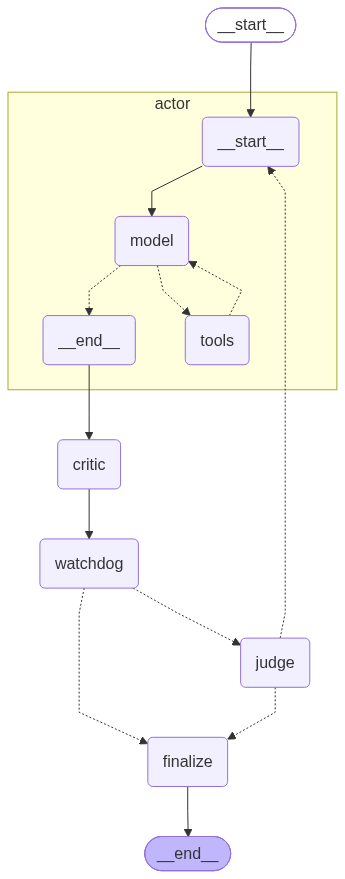

In [41]:
display(Image(
    g.get_graph(xray=True).draw_mermaid_png()
))